In [15]:
import matplotlib.pyplot as plt

In [12]:
import pandas as pd

In [13]:
df=pd.read_csv('google.csv')

In [14]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [5]:
df=pd.DataFrame({'Year':[2021,2022,2023,2024,2025],'Sales':[10000,7000,15000,17000,20000]})

In [6]:
df

,Year,Sales
0,2021,10000
1,2022,7000
2,2023,15000
3,2024,17000
4,2025,20000


Text(0, 0.5, 'Sales')

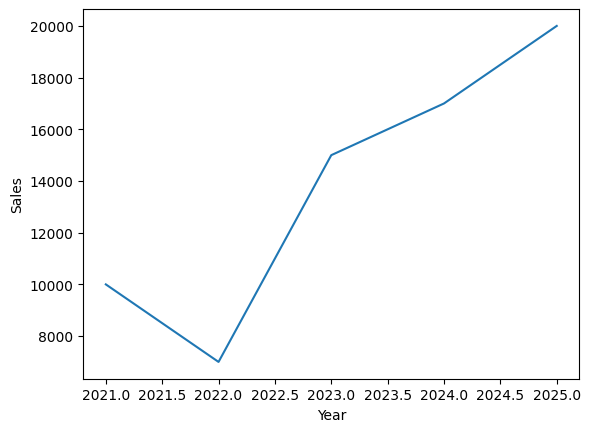

In [7]:
plt.plot(df['Year'],df['Sales'])
plt.xlabel("Year")
plt.ylabel("Sales")

In [8]:
df=df.sort_values('Year')

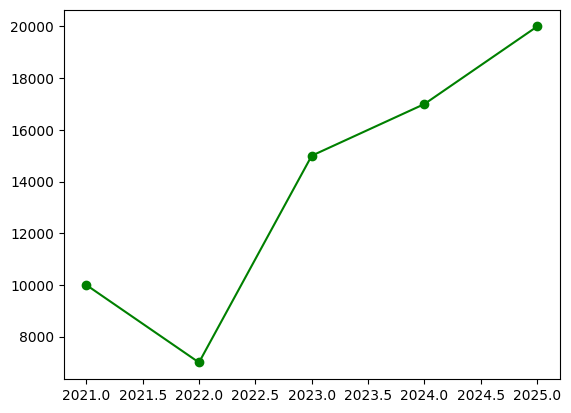

In [9]:
plt.plot(df['Year'],df['Sales'],color='green',marker='o',label='Year v/s Sales')

In [10]:
df['Last Updated'] #"1.0.19" 1)replace it with nan 2)replace with January 1,2019 

KeyError: 'Last Updated'

In [ ]:
df['Last Updated']=df['Last Updated'].replace({'1.0.19':'January 1, 2018'})

In [ ]:
df['Last Updated']=pd.to_datetime(df['Last Updated'])

In [ ]:
df['Year']=df['Last Updated'].dt.year
df['Year']

0        2018
1        2018
2        2018
3        2018
4        2018
         ... 
10836    2017
10837    2018
10838    2017
10839    2015
10840    2018
Name: Year, Length: 10841, dtype: int32

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
group_years=df.groupby('Year')
year_avg_rating=group_years['Rating'].mean()
year_avg_rating

Year
2010    4.200000
2011    3.966667
2012    3.785714
2013    4.073404
2014    4.037895
2015    4.067268
2016    4.041782
2017    4.094793
2018    4.246797
Name: Rating, dtype: float64

In [ ]:
df.dtypes

App                          str
Category                     str
Rating                   float64
Reviews                      str
Size                         str
Installs                     str
Type                         str
Price                        str
Content Rating               str
Genres                       str
Last Updated      datetime64[us]
Current Ver                  str
Android Ver                  str
Year                       int32
dtype: object

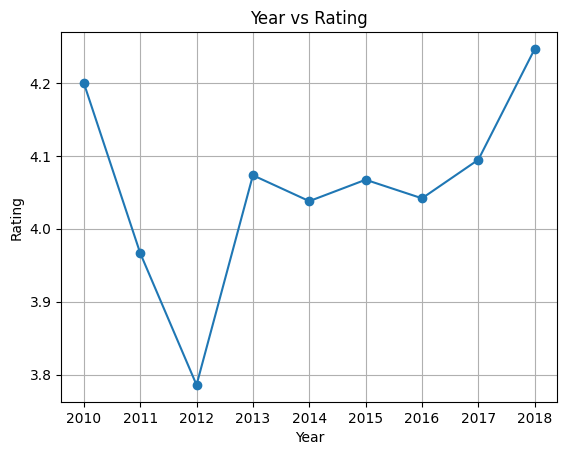

In [ ]:
plt.plot(year_avg_rating,marker='o')
plt.xticks(year_avg_rating.index)
plt.xlabel("Year")
plt.ylabel("Rating")
plt.title("Year vs Rating")
plt.grid()

In [ ]:
def install(val):
    if ',' in val or '+' in val:
        return float (val.replace(',','').replace('+',''))
    if val=='Free':
        return None

In [ ]:
for i in df['Installs']:
    if i[-1].isalpha():
        print(i)

Free


In [ ]:
df['Installs']=df['Installs']

In [ ]:
df['Installs']=df['Installs'].str.replace(',','')

df['Installs']=df['Installs'].str.removesuffix('+')
df['Installs']=df['Installs'].replace({'Free':None})
df['Installs']=df['Installs'].astype(float)

In [ ]:
#year wise installs
group_years=df.groupby('Year')
year_avg_installs=group_years['Installs'].mean()
year_avg_installs

Year
2010    1.000000e+05
2011    1.160473e+06
2012    5.381619e+05
2013    9.381033e+05
2014    1.291657e+06
2015    9.249270e+05
2016    1.743154e+06
2017    2.180747e+06
2018    2.195282e+07
Name: Installs, dtype: float64

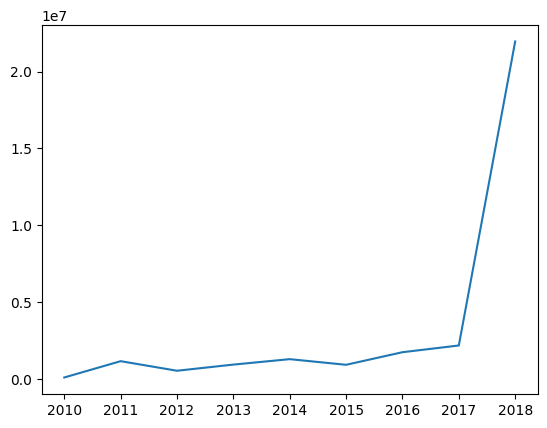

In [ ]:
plt.plot(year_avg_installs)

In [70]:
df['Rating']=df['Rating'].astype(float)

In [ ]:
group_year=df.groupby('Year')
year_avg_Rating=group_year['Rating'].mean()
year_avg_rating

Year
2010    4.200000
2011    3.966667
2012    3.785714
2013    4.073404
2014    4.037895
2015    4.067268
2016    4.041782
2017    4.094793
2018    4.246797
Name: Rating, dtype: float64

In [ ]:
df['Price']=df['Price'].str.removeprefix('$')
df['Price']=df['Price'].replace({'Everyone':None})
df['Price']=df['Price'].astype(float)

In [ ]:
group_year=df.groupby('Year')
year_avg_Price=group_year['Price'].mean()
year_avg_Price

Year
2010    0.000000
2011    0.498667
2012    0.318077
2013    0.921364
2014    1.362919
2015    1.330370
2016    0.570746
2017    1.976551
2018    0.813033
Name: Price, dtype: float64

In [ ]:
group_year=df.groupby('Year')
year_avg_Installs=group_year['Installs'].sum()
year_avg_Installs

Year
2010    1.000000e+05
2011    1.740710e+07
2012    1.399221e+07
2013    1.031914e+08
2014    2.699562e+08
2015    4.245415e+08
2016    1.401496e+09
2017    4.071455e+09
2018    1.613313e+11
Name: Installs, dtype: float64

In [ ]:
group_year=df.groupby('Year')
year_avg_Installs=group_year['App'].value_counts()
year_avg_Installs

Year  App                                           
2010  FML F*ck my life + widget                         1
2011  CF-Bench Pro                                      1
      FD Shift Calendar Widget                          1
      Bubble                                            1
      CJ Poker Odds Calculator                          1
                                                       ..
2018  Logo Maker - Small Business                       1
      ibis Paint X                                      1
      FlipaClip - Cartoon animation                     1
      iHoroscope - 2018 Daily Horoscope & Astrology     1
      Photo Editor & Candy Camera & Grid & ScrapBook    1
Name: count, Length: 9667, dtype: int64

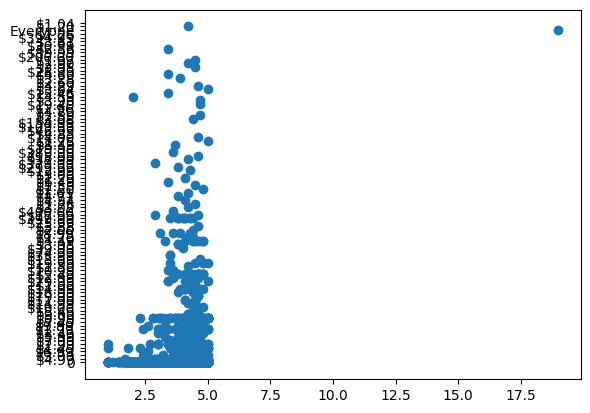

In [ ]:
#scatter plot-
plt.scatter(df['Rating'],df['Price'])

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


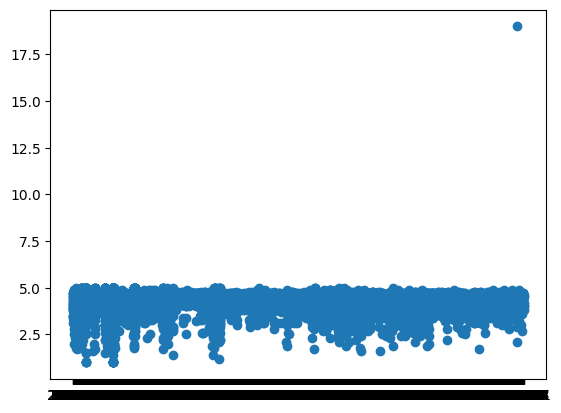

In [ ]:
plt.scatter(df['Reviews'],df['Rating'])

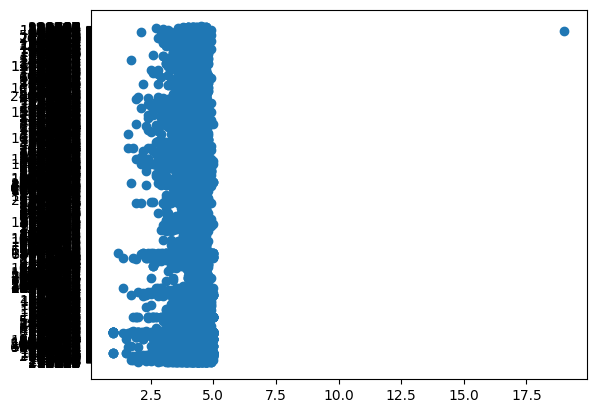

In [ ]:
plt.scatter(df['Rating'],df['Reviews'])

In [ ]:
#for cleaning the column

df['Price']=df['Price'].str.replace('$','')
df['Price']=df['Price'].replace({'Everyone':None})
df['Price']=df['Price'].astype(float)

In [67]:
df['Installs']=df['Installs'].str.replace(',','')
df['Installs']=df['Installs'].str.removesuffix('+')
df['Installs']=df['Installs'].replace({'Free':None})
df['Installs']=df['Installs'].astype(float)

In [69]:
df['Reviews']=df['Reviews'].str.removesuffix('M')
df['Reviews']=df['Reviews'].astype(float)

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:
df.corr(numeric_only=True)

,Rating,Reviews,Installs
Rating,1.000000,0.064841,0.051355
Reviews,0.064841,1.000000,0.643122
Installs,0.051355,0.643122,1.000000


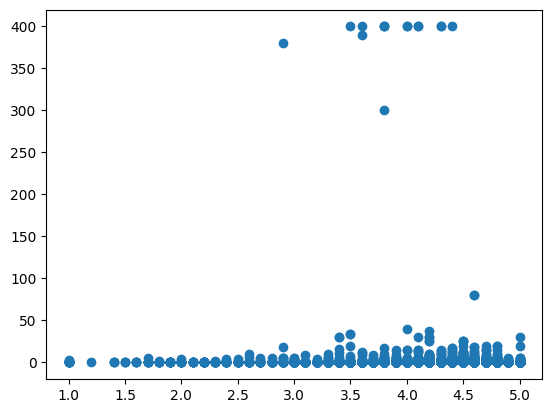

In [ ]:
plt.scatter(df['Rating'],df['Price'])

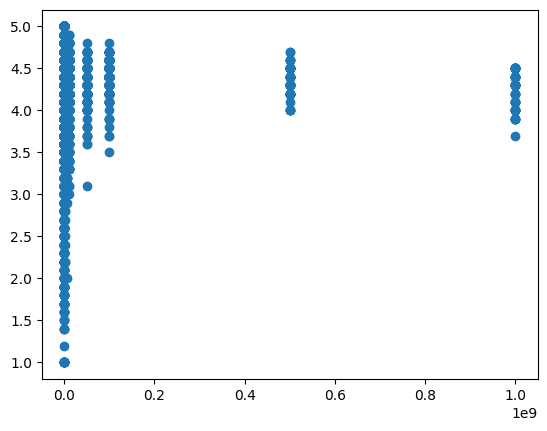

In [ ]:
plt.scatter(df['Installs'],df['Rating'])

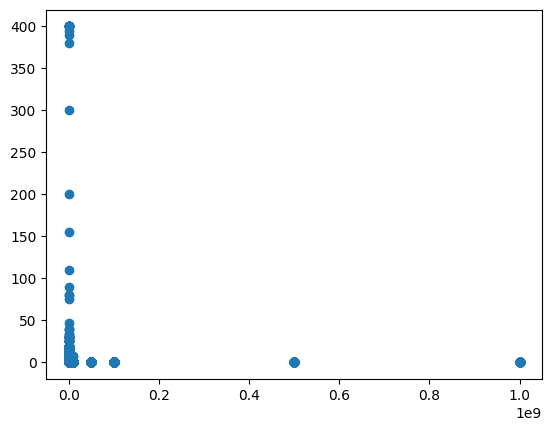

In [ ]:
plt.scatter(df['Installs'],df['Price'])

In [ ]:
def outliers(col):
    l=[]
    for val in df[col]:
        if abs(val)>3:
            l.append(val)
    return l
x=outliers('Rating_Z')
len(x)

151

In [ ]:
def z_score(col):
    X=df[col]
    x_mean=df[col].mean()
    x_std=df[col].std()
    return (X-x_mean)/x_std
#z_score('Rating')
df['Rating_Z']=z_score('Rating')
df['Rating_Z']
        

0       -0.173675
1       -0.545815
2        0.942747
3        0.570606
4        0.198466
           ...   
10836    0.570606
10837    1.500958
10838         NaN
10839    0.570606
10840    0.570606
Name: Rating_Z, Length: 10841, dtype: float64

In [ ]:
#or
def score(col):
    Y=(df[col]-df[col].mean())/df[col].std()
    return Y
score('Rating')

0       -0.173675
1       -0.545815
2        0.942747
3        0.570606
4        0.198466
           ...   
10836    0.570606
10837    1.500958
10838         NaN
10839    0.570606
10840    0.570606
Name: Rating, Length: 10841, dtype: float64

In [ ]:
def z_score(col):
    X=df[col]
    x_mean=df[col].mean()
    x_std=df[col].std()
    return (X-x_mean)/x_std
z_score('Reviews')
#df['Installs_Z']=z_score('Installs')
#df['Installs_Z']

TypeError: Cannot perform reduction 'mean' with string dtype

In [ ]:
def outliers(col):
    l=[]
    for val in df[col]:
        if abs(val)>3:
            l.append(val)
    return l
x=outliers('Price_Z')
len(x)

KeyError: 'Price_Z'

In [ ]:
df=df.dropna()

In [ ]:
df['Rating_Z']

0       -0.173675
1       -0.545815
2        0.942747
3        0.570606
4        0.198466
           ...   
10834   -0.359745
10836    0.570606
10837    1.500958
10839    0.570606
10840    0.570606
Name: Rating_Z, Length: 9360, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x285b06ad010>,
 'caps': [<matplotlib.lines.Line2D at 0x285b06ad2b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x285b06acec0>],
 'medians': [<matplotlib.lines.Line2D at 0x285b06ad550>],
 'fliers': [<matplotlib.lines.Line2D at 0x285b06ad6a0>],
 'means': []}

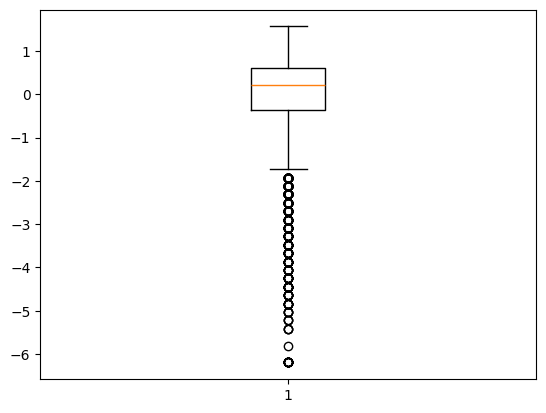

In [ ]:
plt.boxplot(df['Rating_Z'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1f767b127b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1f767b12a50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f767b12660>],
 'medians': [<matplotlib.lines.Line2D at 0x1f767b12cf0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f767b12e40>],
 'means': []}

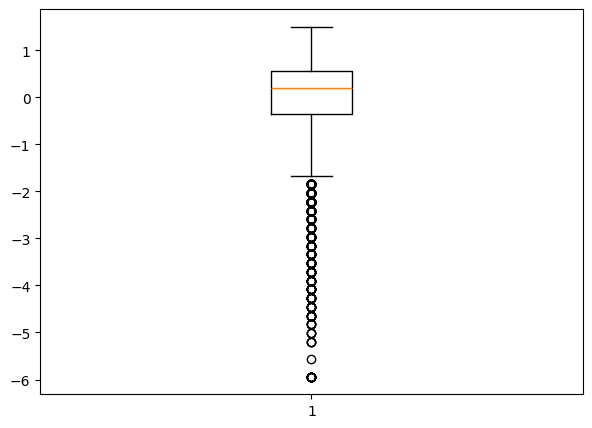

In [ ]:
plt.figure(figsize=(7,5))
plt.boxplot(df['Rating_Z'])

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Rating_Z
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,-0.173675
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,-0.545815
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,0.942747
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,0.570606
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,0.198466


In [ ]:
bar=df.groupby('Category')['Rating'].mean()

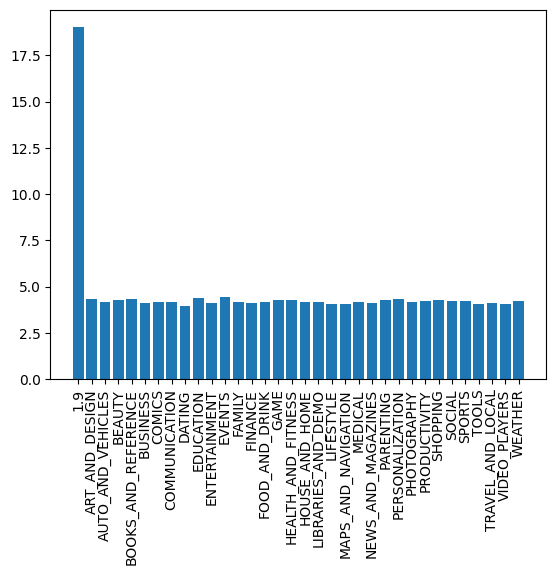

In [ ]:
plt.bar(bar.index,bar.values)
plt.xticks(rotation=90)
plt.show()

In [ ]:
cat=df.groupby('Category')['Installs'].sum()

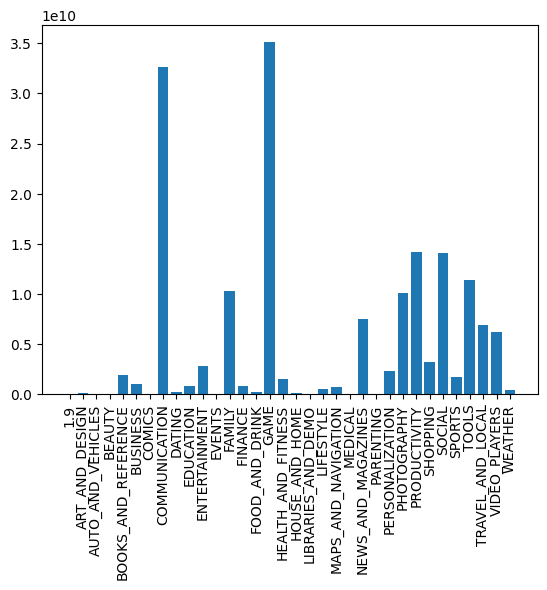

In [ ]:
plt.bar(cat.index,cat.values)
plt.xticks(rotation=90)
plt.show()

In [21]:
Category_vc=df['Category'].value_counts().head(10)

In [22]:
Category_vc.values

array([1972, 1144,  843,  463,  460,  424,  392,  387,  384,  382])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'FAMILY'),
  Text(1, 0, 'GAME'),
  Text(2, 0, 'TOOLS'),
  Text(3, 0, 'MEDICAL'),
  Text(4, 0, 'BUSINESS'),
  Text(5, 0, 'PRODUCTIVITY'),
  Text(6, 0, 'PERSONALIZATION'),
  Text(7, 0, 'COMMUNICATION'),
  Text(8, 0, 'SPORTS'),
  Text(9, 0, 'LIFESTYLE')])

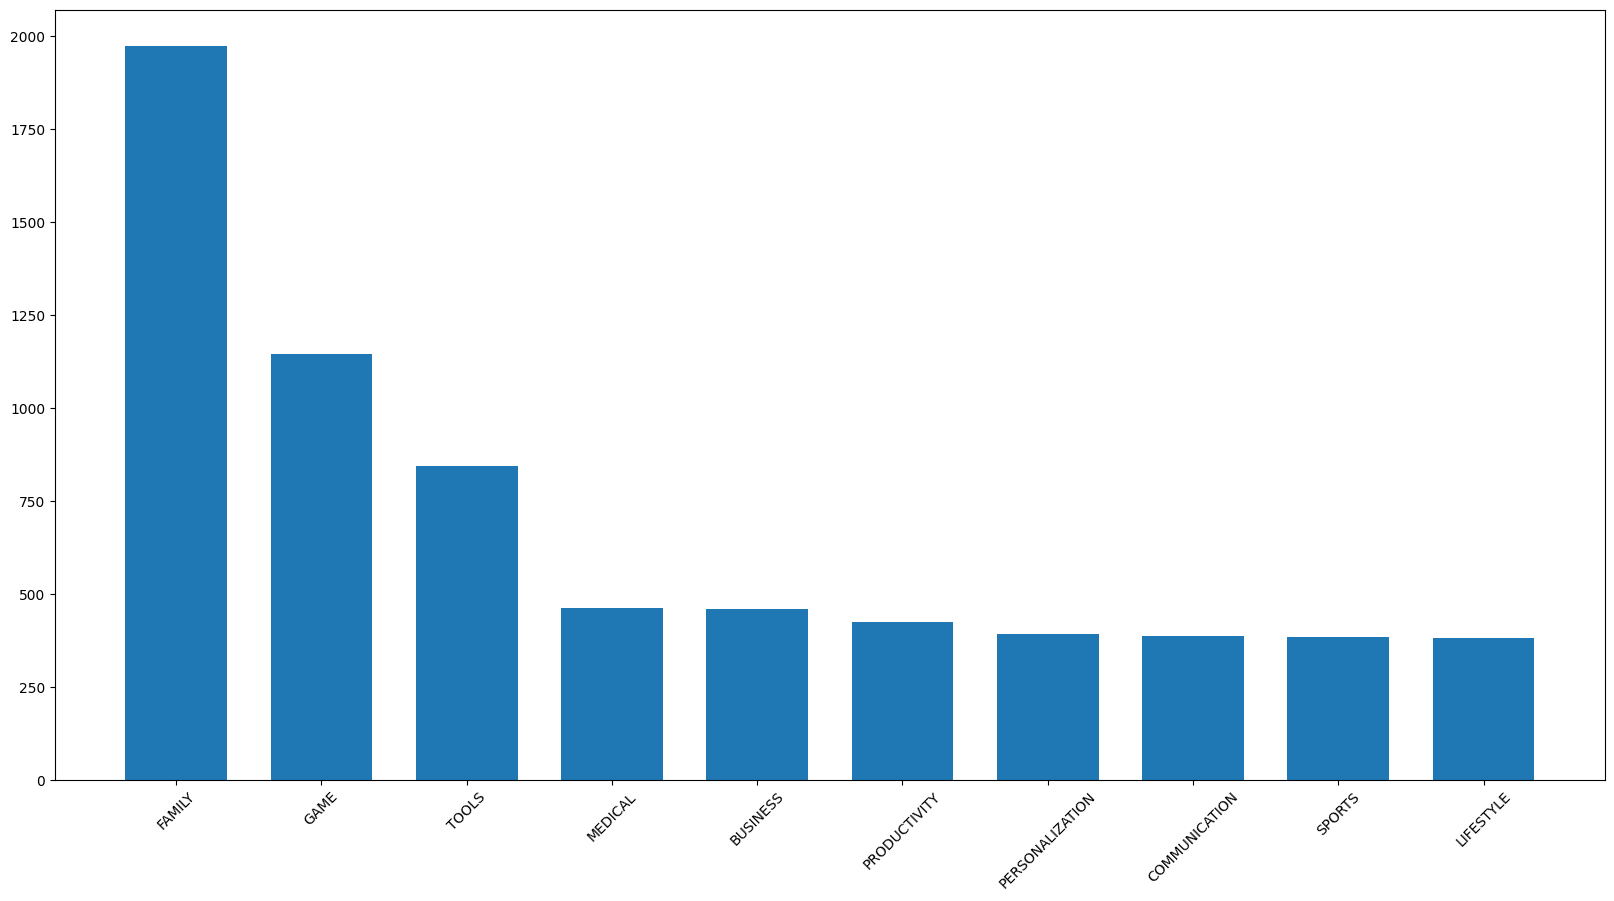

In [ ]:
plt.figure(figsize=(20,10))
plt.bar(Category_vc.index,Category_vc.values,width=0.7)
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'FAMILY'),
  Text(1, 0, 'GAME'),
  Text(2, 0, 'TOOLS'),
  Text(3, 0, 'MEDICAL'),
  Text(4, 0, 'BUSINESS'),
  Text(5, 0, 'PRODUCTIVITY'),
  Text(6, 0, 'PERSONALIZATION'),
  Text(7, 0, 'COMMUNICATION'),
  Text(8, 0, 'SPORTS'),
  Text(9, 0, 'LIFESTYLE')])

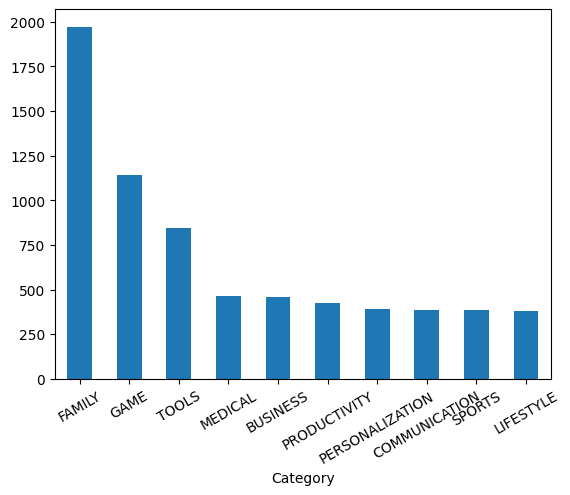

In [19]:
#2nd method without using mathplotlib
Category_vc.plot(kind='bar')
plt.xticks(rotation=30)

In [33]:
app_bar=df['App'].value_counts().head(10)

In [34]:
app_bar.values

array([9, 8, 7, 7, 7, 7, 6, 6, 6, 6])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'ROBLOX'),
  Text(1, 0, 'CBS Sports App - Scores, News, Stats & Watch Live'),
  Text(2, 0, 'Duolingo: Learn Languages Free'),
  Text(3, 0, 'Candy Crush Saga'),
  Text(4, 0, '8 Ball Pool'),
  Text(5, 0, 'ESPN'),
  Text(6, 0, 'Nick'),
  Text(7, 0, 'Subway Surfers'),
  Text(8, 0, 'Bubble Shooter'),
  Text(9, 0, 'slither.io')])

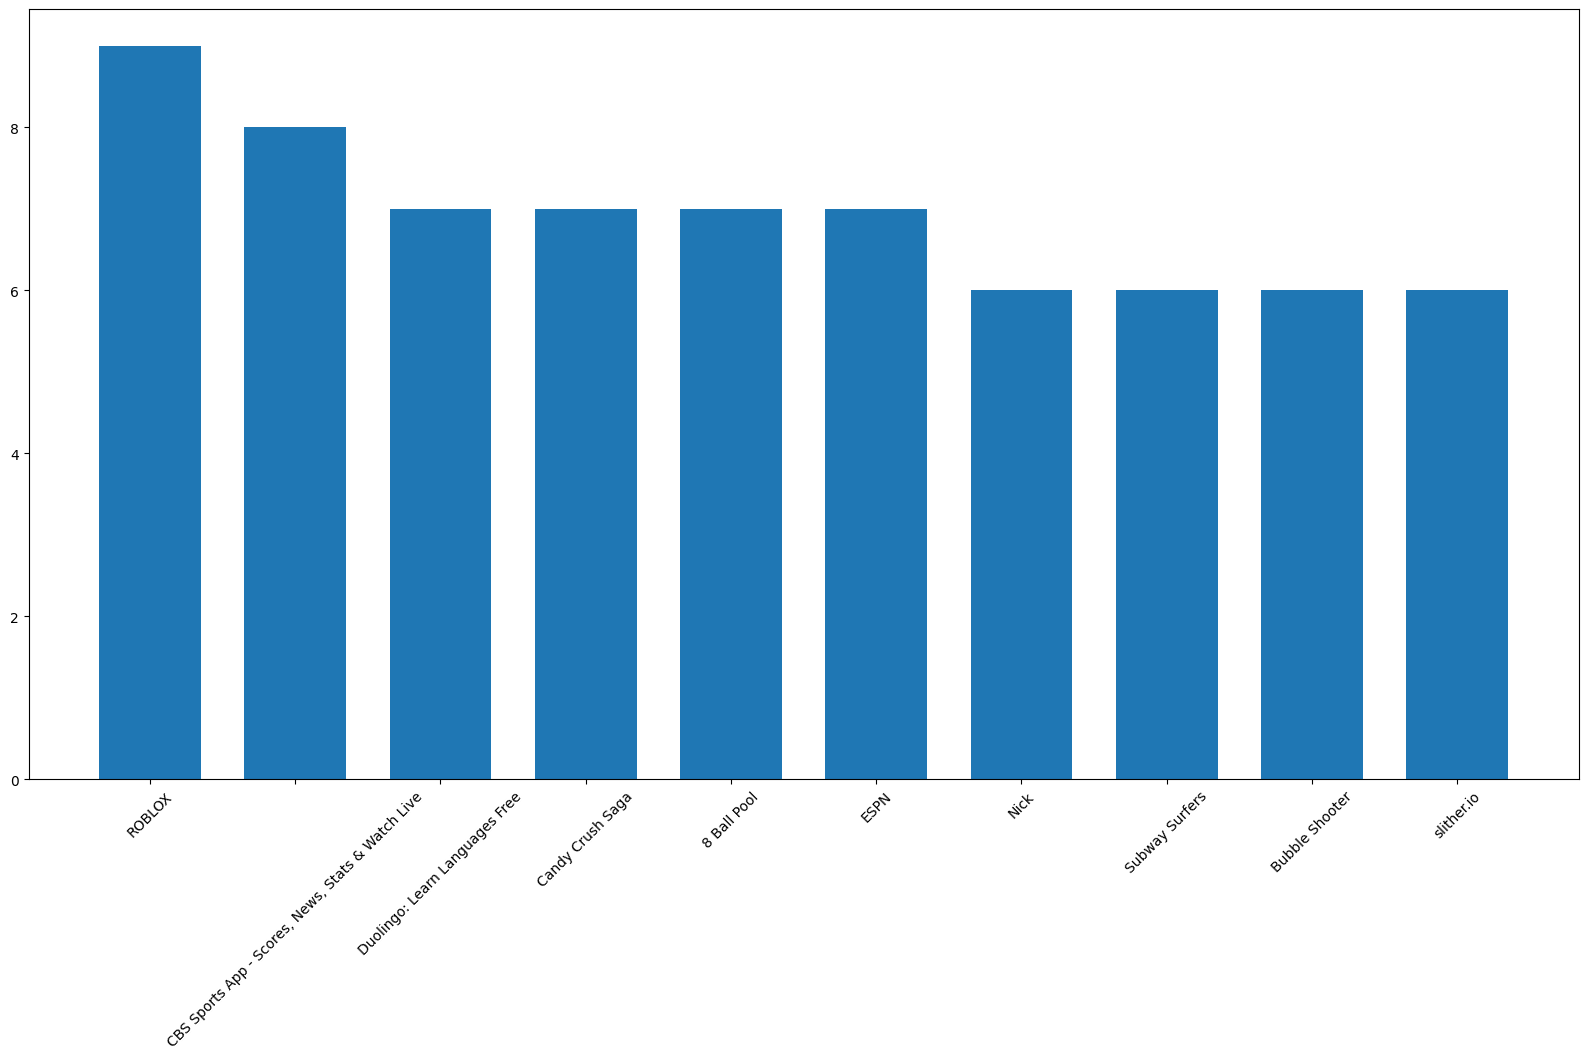

In [35]:
plt.figure(figsize=(20,10))
plt.bar(app_bar.index,app_bar.values,width=0.7)
plt.xticks(rotation=45)

In [ ]:
d={'Names':['Kruthi','Manya','Priya','Nissu','Bindhu','R','HM','MM','HD','MC'],
    'Marks':[100,18,80,60,50,75,98,26,59,82]}

In [ ]:
pd.DataFrame(d)

,Names,Marks
0,Kruthi,100
1,Manya,18
2,Priya,80
3,Nissu,60
4,Bindhu,50
5,R,75
6,HM,98
7,MM,26
8,HD,59
9,MC,82


In [ ]:
dataframe_bar=d['Names'].value_counts().head(10)

AttributeError: 'list' object has no attribute 'value_counts'

In [ ]:
Rate_bar=df['Ratings'].mean().head(10)

KeyError: 'Ratings'

In [20]:
Category_vc.head(10)

Category
FAMILY             1972
GAME               1144
TOOLS               843
MEDICAL             463
BUSINESS            460
PRODUCTIVITY        424
PERSONALIZATION     392
COMMUNICATION       387
SPORTS              384
LIFESTYLE           382
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x1d522ff86e0>,
 [Text(0.6800769591266935, 0.8645781223608365, 'FAMILY'),
  Text(-0.7596895643763364, 0.7955323788367713, 'GAME'),
  Text(-1.0942020883553807, -0.11279091203959614, 'TOOLS'),
  Text(-0.840194099687556, -0.7099816017688187, 'MEDICAL'),
  Text(-0.47444622865142055, -0.9924216725356436, 'BUSINESS'),
  Text(-0.0446281327834302, -1.0990943225057004, 'PRODUCTIVITY'),
  Text(0.360193877450924, -1.0393557478779194, 'PERSONALIZATION'),
  Text(0.7008865230615745, -0.8477960142573551, 'COMMUNICATION'),
  Text(0.9510688243682569, -0.5526916783476858, 'SPORTS'),
  Text(1.0831667544400156, -0.19170232673570492, 'LIFESTYLE')])

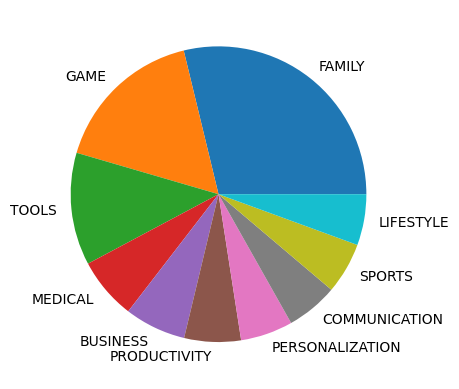

In [ ]:
#Pie chart without %
plt.pie(Category_vc.values,labels=Category_vc.index)

([<matplotlib.patches.Wedge at 0x1d523051950>,
 [Text(0.6800769591266935, 0.8645781223608365, 'FAMILY'),
  Text(-0.7596895643763364, 0.7955323788367713, 'GAME'),
  Text(-1.0942020883553807, -0.11279091203959614, 'TOOLS'),
  Text(-0.840194099687556, -0.7099816017688187, 'MEDICAL'),
  Text(-0.47444622865142055, -0.9924216725356436, 'BUSINESS'),
  Text(-0.0446281327834302, -1.0990943225057004, 'PRODUCTIVITY'),
  Text(0.360193877450924, -1.0393557478779194, 'PERSONALIZATION'),
  Text(0.7008865230615745, -0.8477960142573551, 'COMMUNICATION'),
  Text(0.9510688243682569, -0.5526916783476858, 'SPORTS'),
  Text(1.0831667544400156, -0.19170232673570492, 'LIFESTYLE')],
 [Text(0.37095106861456006, 0.47158806674227444, '28.8%'),
  Text(-0.41437612602345614, 0.4339267520927843, '16.7%'),
  Text(-0.5968375027392985, -0.06152231565796153, '12.3%'),
  Text(-0.4582876907386668, -0.3872626918739011, '6.8%'),
  Text(-0.25878885199168394, -0.5413209122921692, '6.7%'),
  Text(-0.024342617881871014, -0.59950

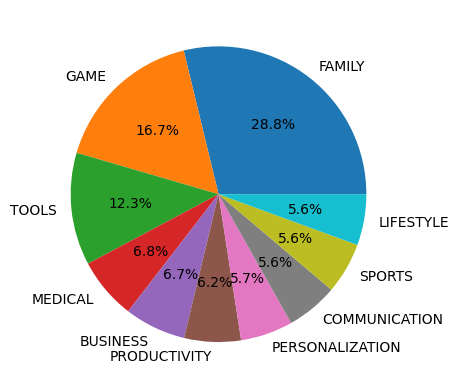

In [ ]:
#Pie chart with % by autopct
plt.pie(Category_vc.values,labels=Category_vc.index,autopct="%1.1f%%")

In [ ]:
#to get categorical columns from the table
df.select_dtypes(include='object').columns

Index(['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [ ]:
df.select_dtypes(include='object')

,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [29]:
df.select_dtypes(exclude='object')

,Rating
0,4.1
1,3.9
2,4.7
3,4.5
4,4.3
...,...
10836,4.5
10837,5.0
10838,NaN
10839,4.5


In [30]:
df.select_dtypes(include='int')

""
0
1
2
3
4
...
10836
10837
10838
10839


In [31]:
#to get unique values (number of unique values)
df.select_dtypes(include='object').nunique()

C:\Users\kruth\AppData\Local\Temp\ipykernel_10900\1988038975.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


App               9660
Category            34
Reviews           6002
Size               462
Installs            22
Type                 3
Price               93
Content Rating       6
Genres             120
Last Updated      1378
Current Ver       2832
Android Ver         33
dtype: int64

([<matplotlib.patches.Wedge at 0x1d52332d310>,
 [Text(1.0089324283623038, 0.43824120641371106, 'ROBLOX'),
  Text(0.4151611134496527, 1.018646773852077, 'CBS Sports App - Scores, News, Stats & Watch Live'),
  Text(-0.3208105171627717, 1.0521789829101107, 'Duolingo: Learn Languages Free'),
  Text(-0.8839943676232465, 0.6546403272105812, 'Candy Crush Saga'),
  Text(-1.0999999999999959, -9.616505800409723e-08, '8 Ball Pool'),
  Text(-0.8839942531622783, -0.6546404817730613, 'ESPN'),
  Text(-0.3683679845309089, -1.036486868210416, 'Nick'),
  Text(0.22380106955270015, -1.0769926096622333, 'Subway Surfers'),
  Text(0.7508079630926697, -0.8039200224877077, 'Bubble Shooter'),
  Text(1.0592088011465333, -0.29677721538845236, 'slither.io')],
 [Text(0.5503267791067111, 0.23904065804384236, '13.0%'),
  Text(0.22645151642708322, 0.5556255130102238, '11.6%'),
  Text(-0.1749875548160573, 0.5739158088600603, '10.1%'),
  Text(-0.4821787459763162, 0.3570765421148624, '10.1%'),
  Text(-0.5999999999999978,

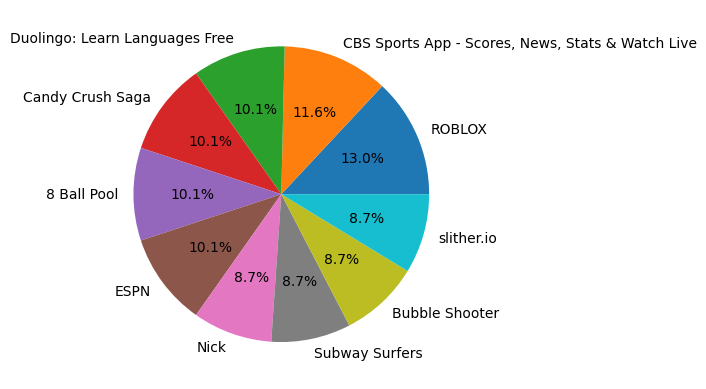

In [36]:
plt.pie(app_bar.values,labels=app_bar.index,autopct="%1.1f%%")

In [ ]:
rate_pie=df['Rating'].value_counts().head(10)

In [39]:
rate_pie.values

array([1109, 1076, 1038,  952,  823,  708,  568,  499,  386,  303])

In [64]:
rat=df.groupby('Rating')['Installs'].head(10)

In [54]:
rat.values

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [62]:
Installs_=df['Installs'].value_counts().head(10)

([<matplotlib.patches.Wedge at 0x1d52367e0d0>,
 [Text(0.9822635240741047, 0.4951346981110503, '4.4'),
  Text(0.2012407455419349, 1.0814352326116097, '4.3'),
  Text(-0.7137059725522386, 0.8370327262080399, '4.5'),
  Text(-1.099600712269578, 0.029635680795907934, '4.2'),
  Text(-0.826731267222687, -0.7256138172584439, '4.6'),
  Text(-0.22486603715274983, -1.0767707580238322, '4.1'),
  Text(0.357837351225952, -1.0401694237323047, '4.0'),
  Text(0.7740425760739216, -0.7815741106413694, '4.7'),
  Text(1.0054518651330595, -0.44616874263046724, '3.9'),
  Text(1.0910618447933706, -0.13994302710777393, '3.8')],
 [Text(0.5357801040404206, 0.2700734716969365, '14.9%'),
  Text(0.10976767938650994, 0.5898737632426961, '14.4%'),
  Text(-0.3892941668466755, 0.4565633052043854, '13.9%'),
  Text(-0.599782206692497, 0.01616491679776796, '12.8%'),
  Text(-0.450944327576011, -0.39578935486824207, '11.0%'),
  Text(-0.12265420208331808, -0.5873295043766357, '9.5%'),
  Text(0.19518400975961017, -0.5673651402

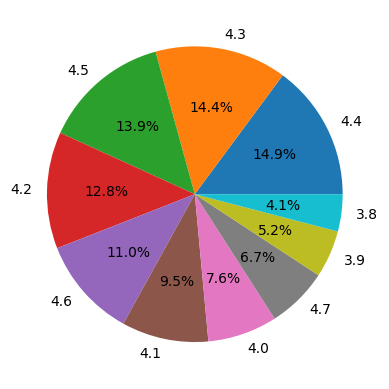

In [42]:
plt.pie(rate_pie.values,labels=rate_pie.index,autopct="%1.1f%%")

In [59]:
install_pie=df['Installs'].value_counts().head(10)

([<matplotlib.patches.Wedge at 0x1d528b30050>,
 [Text(0.9822635240741047, 0.4951346981110503, '1,000,000+'),
  Text(0.2012407455419349, 1.0814352326116097, '10,000,000+'),
  Text(-0.7137059725522386, 0.8370327262080399, '100,000+'),
  Text(-1.099600712269578, 0.029635680795907934, '10,000+'),
  Text(-0.826731267222687, -0.7256138172584439, '1,000+'),
  Text(-0.22486603715274983, -1.0767707580238322, '5,000,000+'),
  Text(0.357837351225952, -1.0401694237323047, '100+'),
  Text(0.7740425760739216, -0.7815741106413694, '500,000+'),
  Text(1.0054518651330595, -0.44616874263046724, '50,000+'),
  Text(1.0910618447933706, -0.13994302710777393, '5,000+')],
 [Text(0.5357801040404206, 0.2700734716969365, '14.9%'),
  Text(0.10976767938650994, 0.5898737632426961, '14.4%'),
  Text(-0.3892941668466755, 0.4565633052043854, '13.9%'),
  Text(-0.599782206692497, 0.01616491679776796, '12.8%'),
  Text(-0.450944327576011, -0.39578935486824207, '11.0%'),
  Text(-0.12265420208331808, -0.5873295043766357, '9.

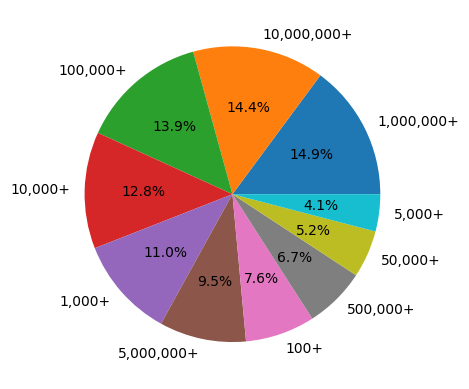

In [71]:
plt.pie(rate_pie.values,labels=Installs_.index,autopct="%1.1f%%")